# ForestWatch Papua — Full Pipeline (v2: EDA-First)

**Deteksi tutupan lahan & perubahan hutan Papua 2021→2025 dari Sentinel-2.**

Notebook ini dirombak dengan prinsip **EDA di awal**: kita validasi ke-6 dataset
sumber **dan** hasil label fusion **SEBELUM** ekspor GEE yang mahal (berjam-jam
ekspor + cut patch). Tujuannya menghindari pengulangan kesalahan label fusion
(EDA versi lama: Hutan cuma 24% & Sawit 0% — tidak masuk akal untuk Papua).

**Alur 15 bagian:** 0 Setup · 1 Sumber data · 2 EDA validasi sumber ·
3 EDA distribusi pra-fusion · 4 EDA visual & agreement · 5 Label fusion ·
6 EDA pasca-fusion (GATE) · 7 Ekspor ubin · 8 Cut patches (paralel) ·
9 Audit ubin · 10 EDA pasca-preprocessing · 11 Train · 12 Evaluasi ·
13 Inferensi · 14 Output + ringkasan.

**Perubahan metodologi inti:** label fusion kini memakai **Dynamic World sebagai
peta dasar** (remap 9→7 kelas) + overlay tematik (Hansen→Deforestasi,
Mining→Tambang, Sawit→FDP Palm 2025a), bukan irisan ketat ESA∩DW yang dulu
menjatuhkan hutan ke Pertanian Lain.

## Bagian 0 — Setup & Konfigurasi (Colab)

Clone repo, install package, mount Drive **Satria Data 3.0**, siapkan path, load
hyperparameter dari `configs/default.yaml`. Output antar-bagian disimpan ke root
Drive sebagai JSON agar tahan restart sesi Colab.

In [1]:
# === COLAB SETUP (clone pertama kali / PULL sesi berikutnya — selalu kode terbaru) ===
# Cukup jalankan ulang sel ini setiap kali ada push baru ke GitHub.
%cd /content
!git -C fw_repo pull -q || git clone --depth 1 https://github.com/Ridho-Dwi-Syahputra/forestwatch-model.git fw_repo
%cd fw_repo
!pip install -q -e ".[gee,gis,ml]"

# Pastikan src package yang terpakai, bukan folder repo
import sys, importlib
if '/content/fw_repo/src' not in sys.path:
    sys.path.insert(0, '/content/fw_repo/src')
# Bersihkan cache import yang salah
for mod in list(sys.modules.keys()):
    if mod == 'forestwatch' or mod.startswith('forestwatch.'):
        del sys.modules[mod]
importlib.invalidate_caches()

print('Python:', sys.version)

try:
    import torch
    print('CUDA available:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
except ImportError:
    print('torch belum ter-install.')

import forestwatch
print(f'forestwatch v{forestwatch.__version__} - {len(forestwatch.CLASS_NAMES)} kelas, {len(forestwatch.BANDS)} band Sentinel-2')


/content
fatal: cannot change to 'fw_repo': No such file or directory
Cloning into 'fw_repo'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 90 (delta 1), reused 57 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 109.99 KiB | 2.24 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/fw_repo
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB

In [2]:
# === MOUNT GOOGLE DRIVE (Colab) ===
from google.colab import drive
drive.mount('/content/drive')
print('Drive ter-mount di /content/drive/MyDrive')

Mounted at /content/drive
Drive ter-mount di /content/drive/MyDrive


In [3]:
# === KONFIGURASI PATH (Drive: Satria Data 3.0) ===
from pathlib import Path

# Colab (default):
DRIVE_ROOT = Path('/content/drive/MyDrive/Satria Data 3.0')
# Lokal Windows alternatif:
# DRIVE_ROOT = Path(r'D:/Local Disk D/Tugas/SATRIA DATA/model/data')

TILES_T1   = DRIVE_ROOT / 'ForestWatch_Tiles_T1'   # GeoTIFF citra 2021
TILES_T2   = DRIVE_ROOT / 'ForestWatch_Tiles_T2'   # GeoTIFF citra 2025 + label
PATCH_DIR  = DRIVE_ROOT / 'ForestWatch_Patches'    # patch .npz training + best_model.pt
MASK_DIR   = DRIVE_ROOT / 'ForestWatch_Masks'      # mask hasil inferensi
OUT_DIR    = DRIVE_ROOT / 'ForestWatch_Outputs'    # 7 file kontrak untuk Orang 2
CKPT_PATH  = PATCH_DIR / 'best_model.pt'

for d in (TILES_T1, TILES_T2, PATCH_DIR, MASK_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Helper IO untuk semua bagian.
from forestwatch.utils.io import save_json, load_json

print('Folder siap di', DRIVE_ROOT)
for d in (TILES_T1, TILES_T2, PATCH_DIR, MASK_DIR, OUT_DIR):
    print(' -', d.name)

Folder siap di /content/drive/MyDrive/Satria Data 3.0
 - ForestWatch_Tiles_T1
 - ForestWatch_Tiles_T2
 - ForestWatch_Patches
 - ForestWatch_Masks
 - ForestWatch_Outputs


In [4]:
# Load konfigurasi default (hyperparameters dari configs/default.yaml)
from forestwatch.config import load_config

cfg = load_config()
print(f"Project    : {cfg['project']['name']}")
print(f"Periode    : T1={cfg['periods']['t1']}, T2={cfg['periods']['t2']}")
print(f"Arsitektur : {cfg['model']['architecture']} + {cfg['model']['encoder_name']}")
print(f"Training   : batch={cfg['training']['batch_size']}, epochs={cfg['training']['epochs']}, lr={cfg['training']['learning_rate']}")
print(f"Patch size : {cfg['patches']['size']}")
print(f"Tiles grid : {cfg['export']['tiles_nx']} x {cfg['export']['tiles_ny']} = {cfg['export']['tiles_nx']*cfg['export']['tiles_ny']} ubin")

Project    : ForestWatch Papua
Periode    : T1=2021, T2=2025
Arsitektur : unet + resnet50
Training   : batch=8, epochs=80, lr=0.001
Patch size : 256
Tiles grid : 6 x 6 = 36 ubin


## Bagian 1 — Sumber Data & Wilayah

Autentikasi GEE (project **forestwatch-papua-unand**), definisikan wilayah Papua
& periode T1=2021 / T2=2025, lalu instansiasi ke-6 dataset sumber.

| # | Sumber | Asset | Peran |
|---|--------|-------|-------|
| 1 | Sentinel-2 SR Harmonized | `COPERNICUS/S2_SR_HARMONIZED` | citra input (6 band) |
| 2 | ESA WorldCover v200 (2021) | `ESA/WorldCover/v200/2021` | cross-check tutupan lahan |
| 3 | Dynamic World V1 (2025) | `GOOGLE/DYNAMICWORLD/V1` | **peta dasar** label (remap 9→7) |
| 4 | Hansen GFC v1.13 (2000–2025) | `UMD/hansen/global_forest_change_2025_v1_13` | Deforestasi (lossyear≥2019) |
| 5 | FDP Palm Probability 2025a | `projects/forestdatapartnership/assets/palm/model_2025a` | Sawit (prob≥0.5) |
| 6 | Global Mining Footprint (Tang & Werner 2023 + Maus dkk. 2022) | `projects/sat-io/open-datasets/global-mining/global_mining_footprints` | Tambang (union poligon) |

> **Sumber Tambang = *union* dua produk footprint:** `…/global_mining_footprints` (Tang & Werner 2023) ∪ `…/global_mining_polygons` (Maus dkk. 2022) → cakupan lebih lengkap (~5,6 rb ha di Papua). Tetap footprint **nyata** (bukan konsesi), jadi tak ada hutan yang tercap tambang.

In [6]:
# === AUTH GEE + WILAYAH + 6 SUMBER ===
import ee
from forestwatch.gee.auth import init_ee
from forestwatch.constants import GEE_ASSETS, PAPUA_BBOX

init_ee(project=cfg['project']['gee_project_id'])   # forestwatch-papua-unand

papua = ee.Geometry.Rectangle(list(PAPUA_BBOX))
T1, T2 = cfg['periods']['t1'], cfg['periods']['t2']
print(f'Wilayah  : Papua bbox {PAPUA_BBOX}')
print(f'Periode  : T1={T1} (pembanding), T2={T2} (label/training)')
print('Asset sumber:')
for k, v in GEE_ASSETS.items():
    print(f'  {k:<16}: {v}')

2026-06-03 06:27:12 [INFO] forestwatch.gee.auth: GEE siap (project=forestwatch-papua-unand).
Wilayah  : Papua bbox (130.0, -9.5, 141.2, 0.5)
Periode  : T1=2021 (pembanding), T2=2025 (label/training)
Asset sumber:
  sentinel2       : COPERNICUS/S2_SR_HARMONIZED
  esa_worldcover  : ESA/WorldCover/v200/2021
  dynamic_world   : GOOGLE/DYNAMICWORLD/V1
  hansen_gfc      : UMD/hansen/global_forest_change_2025_v1_13
  fdp_palm        : projects/forestdatapartnership/assets/palm/model_2025a
  biopama_oilpalm : BIOPAMA/GlobalOilPalm/v1
  mining          : projects/sat-io/open-datasets/global-mining/global_mining_footprints


## Bagian 2 — EDA Sumber #1: Validasi Akses, Versi & Cakupan (GATE)

**Mengapa penting?** Bug "Sawit=0" dulu terjadi karena BIOPAMA dipanggil `.first()`
(1 ubin di luar Papua). Di sini kita pastikan tiap sumber **bisa diakses**, **versi
benar**, dan **punya cakupan di Papua** (mis. poligon tambang > 0, citra DW 2025 > 0,
FDP palm tersedia). Jika ada yang gagal → **berhenti**, jangan lanjut.

Hasil disimpan ke `eda_source_access.json`.

In [7]:
# === EDA #1: validasi akses/versi/cakupan 6 sumber (GATE) ===
import ee, json

report = {}

s2 = (ee.ImageCollection(GEE_ASSETS['sentinel2']).filterBounds(papua)
      .filterDate(f'{T2}-01-01', f'{T2}-12-31'))
report['sentinel2'] = {'asset': GEE_ASSETS['sentinel2'],
                       'n_images_T2': int(s2.size().getInfo())}

esa = ee.Image(GEE_ASSETS['esa_worldcover'])
report['esa_worldcover'] = {'asset': GEE_ASSETS['esa_worldcover'],
                            'bands': esa.bandNames().getInfo()}

dw = (ee.ImageCollection(GEE_ASSETS['dynamic_world']).filterBounds(papua)
      .filterDate(f'{T2}-01-01', f'{T2}-12-31'))
report['dynamic_world'] = {'asset': GEE_ASSETS['dynamic_world'],
                           'n_images_T2': int(dw.size().getInfo())}

hansen = ee.Image(GEE_ASSETS['hansen_gfc'])
report['hansen_gfc'] = {'asset': GEE_ASSETS['hansen_gfc'],
                        'bands': hansen.bandNames().getInfo()}

palm = ee.ImageCollection(GEE_ASSETS['fdp_palm']).filterBounds(papua)
report['fdp_palm'] = {'asset': GEE_ASSETS['fdp_palm'],
                      'n_images': int(palm.size().getInfo())}

mining = ee.FeatureCollection(GEE_ASSETS['mining']).filterBounds(papua)
mining_maus = ee.FeatureCollection(GEE_ASSETS['mining_maus']).filterBounds(papua)
report['mining'] = {'asset': GEE_ASSETS['mining'],
                    'n_polygons_papua': int(mining.size().getInfo())}
report['mining_maus'] = {'asset': GEE_ASSETS['mining_maus'],
                    'n_polygons_papua': int(mining_maus.size().getInfo())}

print(json.dumps(report, indent=2))

# --- GATE cakupan minimum ---
checks = {
    'S2 ada citra T2'         : report['sentinel2']['n_images_T2'] > 0,
    'DW ada citra T2'         : report['dynamic_world']['n_images_T2'] > 0,
    'FDP palm tersedia'       : report['fdp_palm']['n_images'] > 0,
    'Mining poligon di Papua' : report['mining']['n_polygons_papua'] > 0,
    'ESA punya band Map'      : 'Map' in report['esa_worldcover']['bands'],
    'Hansen punya lossyear'   : 'lossyear' in report['hansen_gfc']['bands'],
}
print('\n=== GATE cakupan sumber ===')
for k, v in checks.items():
    print(f"  [{'OK ' if v else 'X  '}] {k}")
save_json(report, DRIVE_ROOT / 'eda_source_access.json')
print('\nDisimpan: eda_source_access.json')
assert all(checks.values()), 'Ada sumber gagal akses/cakupan — perbaiki sebelum lanjut.'
print('GATE LULUS — semua sumber valid & ada cakupan di Papua.')

{
  "sentinel2": {
    "asset": "COPERNICUS/S2_SR_HARMONIZED",
    "n_images_T2": 21008
  },
  "esa_worldcover": {
    "asset": "ESA/WorldCover/v200/2021",
    "bands": [
      "Map"
    ]
  },
  "dynamic_world": {
    "asset": "GOOGLE/DYNAMICWORLD/V1",
    "n_images_T2": 3550
  },
  "hansen_gfc": {
    "asset": "UMD/hansen/global_forest_change_2025_v1_13",
    "bands": [
      "treecover2000",
      "loss",
      "gain",
      "lossyear",
      "first_b30",
      "first_b40",
      "first_b50",
      "first_b70",
      "last_b30",
      "last_b40",
      "last_b50",
      "last_b70",
      "datamask"
    ]
  },
  "fdp_palm": {
    "asset": "projects/forestdatapartnership/assets/palm/model_2025a",
    "n_images": 2
  },
  "mining": {
    "asset": "projects/sat-io/open-datasets/global-mining/global_mining_footprints",
    "n_polygons_papua": 18
  }
}

=== GATE cakupan sumber ===
  [OK ] S2 ada citra T2
  [OK ] DW ada citra T2
  [OK ] FDP palm tersedia
  [OK ] Mining poligon di Papua
  [

## Bagian 3 — EDA Sumber #2: Distribusi Kelas **Pra-Fusion**

Inilah inti pencegahan bug. Kita hitung distribusi kelas dari sumber **mentah** di
3 sub-kotak **darat** Papua (hindari laut yang membiaskan). **Dynamic World harus
menunjukkan Hutan dominan (~75–85%)** — bukti bahwa realita Papua memang hutan.

Jika nanti hasil fusion jauh dari ini (mis. Hutan 24%), berarti logika fusion yang
salah, bukan datanya. Kita juga ukur luas Sawit (FDP palm) & Tambang (mining)
se-Papua. Disimpan ke `eda_source_distribution.json`.

Distribusi Dynamic World (peta dasar) di sampel DARAT — remap 7 kelas:
  Perairan        : 22.94%
  Hutan           : 67.69%
  Deforestasi     :  0.41%
  Sawit           :  0.00%
  Pertanian Lain  :  7.60%
  Tambang         :  0.00%
  Permukiman      :  1.37%

ESA tree_cover di sampel darat : 71.25%
Hansen loss (>=2019)           : 46.01%
Luas Sawit (FDP palm) se-Papua : 279,029 ha
Luas Tambang se-Papua          : 4,059 ha
Luas Permukiman (DW Built)     : 86,883 ha

Validasi sumber per kelas (7 label):
  [OK ] Perairan (0)         <- DW water/flooded + ESA water
  [OK ] Hutan (1)            <- DW trees + ESA tree_cover
  [OK ] Deforestasi/LT (2)   <- DW bare/snow + Hansen loss
  [OK ] Sawit (3)            <- FDP Palm prob>=ambang
  [OK ] Pertanian Lain (4)   <- DW grass/crops/shrub
  [OK ] Tambang (5)          <- Global Mining Footprint
  [OK ] Permukiman (6)       <- DW Built + ESA Built-up


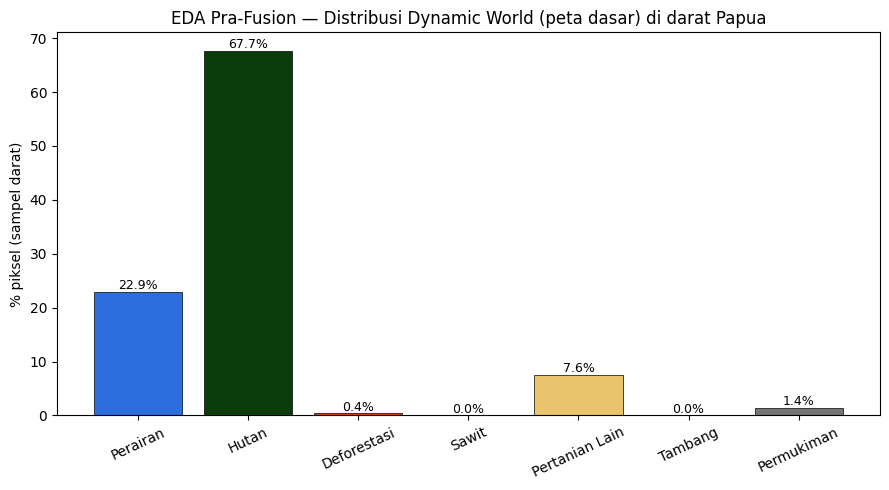


Harapan: Hutan DOMINAN (~75-85%). Jika ya → data sehat, lanjut fusion.


In [8]:
# === EDA #2: distribusi kelas PRA-fusion (bukti hutan dominan) ===
import ee, json
import matplotlib.pyplot as plt
from forestwatch.constants import DW_TO_CLASS, CLASS_NAMES, CLASS_COLORS

# 3 sub-kotak DARAT representatif.
land_boxes = {
    'Merauke (selatan)'    : [140.0, -8.6, 140.8, -8.0],
    'Dataran tinggi tengah': [137.5, -4.3, 138.3, -3.7],
    'Jayapura (utara)'     : [140.4, -2.8, 141.0, -2.3],
}
land = ee.Geometry.MultiPolygon(
    [ee.Geometry.Rectangle(b).coordinates() for b in land_boxes.values()])
SCALE = 200  # m — agar reduceRegion ringan

dw_mode = (ee.ImageCollection(GEE_ASSETS['dynamic_world']).filterBounds(land)
           .filterDate(f'{T2}-01-01', f'{T2}-12-31').select('label').mode())
esa_img = ee.Image(GEE_ASSETS['esa_worldcover']).select('Map')

def freq_hist(img, band):
    h = img.reduceRegion(ee.Reducer.frequencyHistogram(), land, SCALE,
                         maxPixels=int(1e10)).getInfo()
    return h.get(band, {}) or {}

dw_counts  = freq_hist(dw_mode, 'label')
esa_counts = freq_hist(esa_img, 'Map')

# DW → 7 kelas proyek (pakai DW_TO_CLASS).
proj = {c: 0.0 for c in range(7)}
for k, v in dw_counts.items():
    proj[DW_TO_CLASS[int(float(k))]] += float(v)
tot = sum(proj.values()) or 1.0
dw_pct = {c: 100 * proj[c] / tot for c in range(7)}

# ESA tree_cover (kelas 10) %.
esa_tot = sum(float(v) for v in esa_counts.values()) or 1.0
esa_tree_pct = 100 * float(esa_counts.get('10', 0)) / esa_tot

# Hansen loss (lossyear>=19) % di sampel darat.
hansen_loss_frac = (ee.Image(GEE_ASSETS['hansen_gfc']).select('lossyear').gte(19)
    .reduceRegion(ee.Reducer.mean(), land, SCALE, maxPixels=int(1e10)).getInfo())
hansen_loss_pct = 100 * float(list(hansen_loss_frac.values())[0] or 0)

# Luas Sawit & Tambang se-Papua (di mana memang muncul).
thr = cfg['label_fusion']['palm_prob_threshold']
palm_mosaic = ee.ImageCollection(GEE_ASSETS['fdp_palm']).filterBounds(papua).select('probability').mosaic()
palm_sqm = (palm_mosaic.gte(thr).multiply(ee.Image.pixelArea())
    .reduceRegion(ee.Reducer.sum(), papua, 300, maxPixels=int(1e13)).getInfo())
palm_ha = float(list(palm_sqm.values())[0] or 0) / 1e4

mining_fc_union = (ee.FeatureCollection(GEE_ASSETS['mining']).filterBounds(papua)
                   .merge(ee.FeatureCollection(GEE_ASSETS['mining_maus']).filterBounds(papua)))
mining_img = ee.Image().byte().paint(mining_fc_union, 1)
mining_sqm = (mining_img.multiply(ee.Image.pixelArea())
    .reduceRegion(ee.Reducer.sum(), papua, 300, maxPixels=int(1e13)).getInfo())
mining_ha = float(list(mining_sqm.values())[0] or 0) / 1e4

# Luas Permukiman se-Papua (DW Built = kelas dasar 6).
dw_papua = (ee.ImageCollection(GEE_ASSETS['dynamic_world']).filterBounds(papua)
            .filterDate(f'{T2}-01-01', f'{T2}-12-31').select('label').mode())
built_sqm = (dw_papua.eq(6).multiply(ee.Image.pixelArea())
    .reduceRegion(ee.Reducer.sum(), papua, 300, maxPixels=int(1e13)).getInfo())
permukiman_ha = float(list(built_sqm.values())[0] or 0) / 1e4

# --- Cetak + simpan ---
print('Distribusi Dynamic World (peta dasar) di sampel DARAT — remap 7 kelas:')
for c in range(7):
    print(f'  {CLASS_NAMES[c]:<16}: {dw_pct[c]:5.2f}%')
print(f'\nESA tree_cover di sampel darat : {esa_tree_pct:5.2f}%')
print(f'Hansen loss (>=2019)           : {hansen_loss_pct:5.2f}%')
print(f'Luas Sawit (FDP palm) se-Papua : {palm_ha:,.0f} ha')
print(f'Luas Tambang se-Papua          : {mining_ha:,.0f} ha')
print(f'Luas Permukiman (DW Built)     : {permukiman_ha:,.0f} ha')

# Validasi SUMBER tiap kelas (7 label) — tiap label wajib punya sumber & hadir.
print('\nValidasi sumber per kelas (7 label):')
_sumber = {
    'Perairan (0)'       : ('DW water/flooded + ESA water',  dw_pct[0] > 0),
    'Hutan (1)'          : ('DW trees + ESA tree_cover',      dw_pct[1] > 0),
    'Deforestasi/LT (2)' : ('DW bare/snow + Hansen loss',     (dw_pct[2] > 0) or (hansen_loss_pct > 0)),
    'Sawit (3)'          : ('FDP Palm prob>=ambang',          palm_ha > 0),
    'Pertanian Lain (4)' : ('DW grass/crops/shrub',           dw_pct[4] > 0),
    'Tambang (5)'        : ('Global Mining Footprint',        mining_ha > 0),
    'Permukiman (6)'     : ('DW Built + ESA Built-up',        permukiman_ha > 0),
}
for _k, (_s, _ok) in _sumber.items():
    print(f"  [{'OK ' if _ok else 'X  '}] {_k:<20} <- {_s}")

dist_src = {
    'land_boxes': land_boxes, 'scale_m': SCALE,
    'dw_pct_7class': {CLASS_NAMES[c]: dw_pct[c] for c in range(7)},
    'esa_tree_pct': esa_tree_pct, 'hansen_loss_pct': hansen_loss_pct,
    'palm_ha_papua': palm_ha, 'mining_ha_papua': mining_ha,
    'permukiman_ha_papua': permukiman_ha,
}
save_json(dist_src, DRIVE_ROOT / 'eda_source_distribution.json')

# Bar chart distribusi DW (peta dasar).
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([CLASS_NAMES[c] for c in range(7)], [dw_pct[c] for c in range(7)],
       color=[CLASS_COLORS[c] for c in range(7)], edgecolor='black', linewidth=0.5)
ax.set_ylabel('% piksel (sampel darat)')
ax.set_title('EDA Pra-Fusion — Distribusi Dynamic World (peta dasar) di darat Papua')
ax.tick_params(axis='x', rotation=25)
for i, c in enumerate(range(7)):
    ax.text(i, dw_pct[c] + 0.5, f'{dw_pct[c]:.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig(OUT_DIR / 'eda_prefusion_dw.png', dpi=130, bbox_inches='tight')
plt.show()
print('\nHarapan: Hutan DOMINAN (~75-85%). Jika ya → data sehat, lanjut fusion.')

## Bagian 4 — EDA Sumber #3: Visual & Agreement antar-Sumber

Tampilkan berdampingan RGB Sentinel-2 + tiap sumber pada satu area uji, plus peta
**kesepakatan ESA vs DW** untuk hutan. Di area merah (ESA & DW tak sepakat) itulah
dulu irisan `ESA AND DW` menjatuhkan hutan ke Pertanian Lain. Sekarang DW jadi peta
dasar, jadi ketidaksepakatan tidak lagi menghapus hutan.

> Sel ini interaktif (geemap) — jalankan di Colab untuk melihat peta.

In [9]:
# === EDA #3: visual berdampingan + agreement ESA vs DW (geemap) ===
import ee, geemap
from forestwatch.constants import DW_TO_CLASS

aoi = ee.Geometry.Rectangle([140.0, -8.6, 140.8, -8.0])  # Merauke uji
PALETTE6 = ['2A6FDB', '0B3D0B', 'E03B24', 'F97316', 'E9C46A', '8E24AA', '757575']

s2_rgb = (ee.ImageCollection(GEE_ASSETS['sentinel2']).filterBounds(aoi)
          .filterDate(f'{T2}-01-01', f'{T2}-12-31')
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)).median())
dw_mode = (ee.ImageCollection(GEE_ASSETS['dynamic_world']).filterBounds(aoi)
           .filterDate(f'{T2}-01-01', f'{T2}-12-31').select('label').mode())
dw6 = dw_mode.remap(list(DW_TO_CLASS), [DW_TO_CLASS[k] for k in DW_TO_CLASS])
esa = ee.Image(GEE_ASSETS['esa_worldcover']).select('Map')
hansen_loss = ee.Image(GEE_ASSETS['hansen_gfc']).select('lossyear').gte(19).selfMask()
palm = ee.ImageCollection(GEE_ASSETS['fdp_palm']).filterBounds(aoi).select('probability').mosaic()
mining_fc = (ee.FeatureCollection(GEE_ASSETS['mining']).filterBounds(aoi)
             .merge(ee.FeatureCollection(GEE_ASSETS['mining_maus']).filterBounds(aoi)))

# Agreement hutan: 2=keduanya hutan, 1=hanya satu, 0=bukan hutan keduanya.
agree = esa.eq(10).add(dw_mode.eq(1))

Map = geemap.Map(center=[-8.3, 140.4], zoom=10)
Map.addLayer(s2_rgb, {'bands': ['B4','B3','B2'], 'min':0,'max':3000}, 'S2 RGB 2025')
Map.addLayer(dw6, {'min':0,'max':6,'palette':PALETTE6}, 'DW remap 7 kelas')
Map.addLayer(esa, {}, 'ESA WorldCover', False)
Map.addLayer(agree, {'min':0,'max':2,'palette':['e03b24','f5d000','0b3d0b']},
             'Agreement hutan ESA+DW (merah=beda)')
Map.addLayer(hansen_loss, {'palette':['E03B24']}, 'Hansen loss >=2019', False)
Map.addLayer(palm, {'min':0,'max':1,'palette':['ffffff','F97316']}, 'FDP palm prob', False)
Map.addLayer(mining_fc, {'color':'8E24AA'}, 'Mining poligon', False)
Map

Map(center=[-8.3, 140.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Bagian 5 — Label Fusion (Dynamic World base + overlay tematik)

Metodologi (lihat `forestwatch/gee/label_fusion.py`):

1. **Peta dasar = Dynamic World** (mode tahunan), di-remap 9→7 kelas
   (`constants.DW_TO_CLASS`). Lengkap, tanpa "default Pertanian Lain".
2. *(opsional)* perkuat Hutan dgn ESA tree_cover (UNION — hanya menambah).
3. Overlay tematik berurutan (menimpa):
   **a.** Hansen lossyear≥2019 → **Deforestasi (2)**;
   **b.** poligon Mining (union Tang & Werner + Maus) → **Tambang (5)**;
   **c.** FDP Palm prob≥0.5 → **Sawit (3)** *(paling akhir, agar pasti terwakili)*.

Dengan DW sebagai dasar, hutan tidak lagi "jatuh" ke Pertanian Lain seperti pada
irisan ketat versi lama.

### Alur Fusion per Dataset — cara tiap sumber membentuk 7 label

> **Sentinel-2 = CITRA INPUT (6 band), BUKAN label.** Model belajar memetakan citra S2 → label. Label-nya sendiri dibangun dari 5 sumber tematik berikut, **berurutan** (langkah belakang menimpa yang depan).

| Langkah | Dataset | Aturan | Menghasilkan |
|---|---|---|---|
| ① peta dasar | **Dynamic World** (mode 2025) | remap 9→7 kelas | mengisi SEMUA piksel |
| ② (opsional) | **ESA WorldCover** | `tree_cover` perkuat Hutan (UNION, hanya menambah) | kelas 1 Hutan |
| ③ menimpa | **Hansen GFC** | `lossyear ≥ 2019` (erosi 1 px) | kelas 2 Deforestasi |
| ④ menimpa | **Global Mining Footprint** (union TW + Maus) | rasterisasi poligon tambang | kelas 5 Tambang |
| ⑤ menimpa (TERAKHIR) | **FDP Palm 2025a** | probabilitas ≥ 0.5 | kelas 3 Sawit |

**Remap Dynamic World 9→7 kelas** (`constants.DW_TO_CLASS`):

| DW asli | → kelas kita |
|---|---|
| 0 Water, 3 Flooded veg | **0 Perairan** |
| 1 Trees | **1 Hutan** |
| 7 Bare, 8 Snow | **2 Deforestasi / Lahan Terbuka** |
| 2 Grass, 4 Crops, 5 Shrub | **4 Pertanian Lain** |
| 6 Built | **6 Permukiman** |

```
Sentinel-2 (citra 6 band) ─────────────►  INPUT MODEL (bukan label)

LABEL dibangun:
① Dynamic World (mode 2025) ─remap 9→7─►  PETA DASAR (semua piksel terisi)
② ESA tree_cover (opsional) ─UNION─────►  perkuat Hutan (hanya menambah)
③ Hansen lossyear ≥ 2019    ─TIMPA─────►  kelas 2  Deforestasi
④ Mining (union TW+Maus)   ─TIMPA─────►  kelas 5  Tambang
⑤ FDP Palm prob ≥ 0.5       ─TIMPA─────►  kelas 3  Sawit  (paling akhir)
                                  ▼
                       LABEL 7 KELAS (0..6)
```

**Urutan menimpa:** Sawit > Tambang > Deforestasi > peta dasar DW. Bila satu piksel masuk beberapa sumber, yang menang adalah yang diterapkan paling akhir.

**Mengapa DW jadi peta dasar?** Versi lama men-default-kan tiap piksel ke *Pertanian Lain* lalu Hutan butuh irisan ketat `ESA AND DW` → hutan yang tak disepakati jatuh ke Pertanian Lain (EDA lama: Hutan hanya 24%). DW sebagai peta dasar yang lengkap membuat Hutan dominan otomatis (~75–85%, sesuai realita Papua).

**Catatan label & periode:** label hanya dibangun untuk **T2 (2025)** = data latih. Model lalu memprediksi mask **T1 (2021)** dan **T2 (2025)**; deteksi perubahan membandingkan keduanya (Hutan → X).

> ⚠️ **Prinsip & keterbatasan kelas Tambang:** label berasal dari **union footprint Tang & Werner 2023 + Maus dkk. 2022** (~5.569 ha di Papua, berbasis Sentinel-2 ~2019). Footprint ini = **"guru lokasi"**; model lalu **mempelajari pola spektral tambang dari citra Sentinel-2 2025** di lokasi itu, sehingga saat inferensi bisa menandai tambang serupa yang belum terdata. **Tetap under-capture**: bahkan Grasberg hanya tertangkap sebagian, dan tambang emas rakyat/ilegal sulit dipetakan dataset global mana pun. Catatan jujur: angka Tambang dari model **tidak akan menyamai luas konsesi (~1,2 juta ha)** — itu mayoritas hutan berizin, bukan lahan tergali. Tambang dilaporkan sebagai *kelas dengan keterbatasan data yang diakui terbuka*, bukan dipaksakan.

In [10]:
# === Bangun komposit S2 (T1,T2) + label 7 kelas (DW-base) ===
import ee
from forestwatch.gee.composite import s2_composite
from forestwatch.gee.label_fusion import build_label

lf = cfg['label_fusion']
img_t2 = s2_composite(T2, papua)
img_t1 = s2_composite(T1, papua)
label  = build_label(
    papua, T2,
    hansen_loss_year_min=lf['hansen_loss_year_min'],
    hansen_erosion_pixels=lf['hansen_erosion_pixels'],
    palm_prob_threshold=lf['palm_prob_threshold'],
    esa_forest_union=lf.get('esa_forest_union', False),
)
# .toFloat() WAJIB: img_t2 (Float32) + label (Byte) → hindari error 'inconsistent types'.
stack_t2 = img_t2.addBands(label.toFloat())
print('Komposit S2 (T1 & T2) + label 7 kelas (DW-base) siap.')

Komposit S2 (T1 & T2) + label 7 kelas (DW-base) siap.


In [11]:
# === Visual label final vs RGB (geemap) — warna Tambang = ungu #8E24AA ===
import geemap
PALETTE6 = ['2A6FDB', '0B3D0B', 'E03B24', 'F97316', 'E9C46A', '8E24AA', '757575']
Map2 = geemap.Map(center=[-8.5, 140.4], zoom=9)
Map2.addLayer(stack_t2.select(['B4','B3','B2']), {'min':0,'max':0.3}, 'S2 RGB 2025')
Map2.addLayer(label, {'min':0,'max':6,'palette':PALETTE6}, 'Label fusion 7 kelas')
Map2

Map(center=[-8.5, 140.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Bagian 6 — EDA Pasca-Fusion: **GATE Sebelum Ekspor**

Sebelum menghabiskan berjam-jam ekspor, kita hitung distribusi **label hasil fusion**
di sampel darat + pastikan kelas Sawit & Tambang muncul se-Papua. **Assertions:**
Hutan > 60%, Pertanian Lain < 20%, Deforestasi > 0, Sawit > 0, Tambang > 0.

**Jika GATE GAGAL → STOP. Jangan ekspor.** Perbaiki fusion dulu. Disimpan ke
`eda_fusion_preexport.json`.

In [12]:
# === EDA Pasca-Fusion: GATE sebelum export ===
import ee, json
from forestwatch.constants import CLASS_NAMES

# Distribusi label-fusi di sampel darat (land & SCALE dari Bagian 3).
fh = label.reduceRegion(ee.Reducer.frequencyHistogram(), land, SCALE,
                        maxPixels=int(1e10)).getInfo().get('label', {})
cnt = {c: float(fh.get(str(c), fh.get(f'{c}.0', 0)) or 0) for c in range(7)}
tot = sum(cnt.values()) or 1.0
pct = {c: 100 * cnt[c] / tot for c in range(7)}

# Sawit & Tambang se-Papua (dari Bagian 3).
src = load_json(DRIVE_ROOT / 'eda_source_distribution.json')
palm_ha, mining_ha = src['palm_ha_papua'], src['mining_ha_papua']
permukiman_ha = src.get('permukiman_ha_papua', 0)

print('Distribusi LABEL FUSION (sampel darat):')
for c in range(7):
    print(f'  {CLASS_NAMES[c]:<16}: {pct[c]:5.2f}%')
print(f'\nSawit se-Papua  : {palm_ha:,.0f} ha')
print(f'Tambang se-Papua: {mining_ha:,.0f} ha')
print(f'Permukiman se-Papua: {permukiman_ha:,.0f} ha')

gate = {
    'Hutan dominan (>60%)'      : pct[1] > 60,
    'Pertanian Lain wajar (<20%)': pct[4] < 20,
    'Deforestasi hadir (>0%)'   : pct[2] > 0,
    'Sawit hadir di Papua (>0 ha)' : palm_ha > 0,
    'Tambang hadir di Papua (>0 ha)': mining_ha > 0,
    'Permukiman hadir di Papua (>0 ha)': permukiman_ha > 0,
}
print('\n=== GATE PASCA-FUSION ===')
for k, v in gate.items():
    print(f"  [{'OK ' if v else 'X  '}] {k}")

out = {'pct_land_sample': {CLASS_NAMES[c]: pct[c] for c in range(7)},
       'palm_ha_papua': palm_ha, 'mining_ha_papua': mining_ha,
       'permukiman_ha_papua': permukiman_ha,
       'gate': gate, 'passed': all(gate.values())}
save_json(out, DRIVE_ROOT / 'eda_fusion_preexport.json')

if not all(gate.values()):
    print('\n*** GATE GAGAL — JANGAN EXPORT. Perbaiki label fusion dulu. ***')
    raise AssertionError('GATE pasca-fusion gagal: lihat poin X di atas.')
print('\nGATE LULUS — distribusi label masuk akal. Aman lanjut ke ekspor.')

Distribusi LABEL FUSION (sampel darat):
  Perairan        : 22.74%
  Hutan           : 63.94%
  Deforestasi     :  5.03%
  Sawit           :  0.62%
  Pertanian Lain  :  6.37%
  Tambang         :  0.00%
  Permukiman      :  1.29%

Sawit se-Papua  : 279,029 ha
Tambang se-Papua: 4,059 ha
Permukiman se-Papua: 86,883 ha

=== GATE PASCA-FUSION ===
  [OK ] Hutan dominan (>60%)
  [OK ] Pertanian Lain wajar (<20%)
  [OK ] Deforestasi hadir (>0%)
  [OK ] Sawit hadir di Papua (>0 ha)
  [OK ] Tambang hadir di Papua (>0 ha)
  [OK ] Permukiman hadir di Papua (>0 ha)

GATE LULUS — distribusi label masuk akal. Aman lanjut ke ekspor.


## Bagian 7 — Ekspor Ubin T1 + T2 ke Drive

Bagi Papua jadi grid ubin lalu ekspor GeoTIFF ke Drive (Satria Data 3.0). T2 berisi
6 band + label (untuk training); T1 hanya citra (untuk inferensi pembanding).
Pantau task di GEE Tasks. *(Sub-sel opsional: generate dummy untuk Orang 2.)*

In [ ]:
from forestwatch.gee.tiles import make_tiles
from forestwatch.gee.export import export_tiles_grid

tiles = make_tiles(papua, nx=cfg['export']['tiles_nx'], ny=cfg['export']['tiles_ny'])
print(f'Total tiles: {len(tiles)}')

# T2: citra + label (untuk training)
tasks_t2 = export_tiles_grid(
    stack_t2, tiles,
    name_prefix='papua_t2_tile',
    folder=TILES_T2.name,
    scale=cfg['sentinel2']['scale'],
    max_pixels=int(cfg['export']['max_pixels']),
)

# T1: hanya citra (untuk inferensi T1, lalu deteksi perubahan)
tasks_t1 = export_tiles_grid(
    img_t1, tiles,
    name_prefix='papua_t1_tile',
    folder=TILES_T1.name,
    scale=cfg['sentinel2']['scale'],
    max_pixels=int(cfg['export']['max_pixels']),
)
print(f'Started {len(tasks_t1) + len(tasks_t2)} task. Pantau di GEE Tasks.')

In [ ]:
# (Opsional) Monitor sampai semua task selesai - polling tiap 60 detik (max 6 jam).
# Jangan jalankan jika ingin pakai Colab untuk hal lain - cukup buka GEE Tasks console.

# from forestwatch.gee.export import monitor_tasks
# final_status = monitor_tasks(tasks_t1 + tasks_t2, poll_seconds=60, timeout_seconds=6*3600)
# print('Status akhir:', final_status)

**Opsional (Minggu 1):** generate output dummy untuk Orang 2 (WebGIS) supaya
mereka bisa mulai integrasi sebelum model asli jadi.

In [ ]:
from forestwatch.cli.dummy import main as dummy_main

dummy_out = (DRIVE_ROOT / 'ForestWatch_Outputs_Dummy').as_posix()
dummy_main(['--out', dummy_out, '--n-polygons', '60', '--seed', '42'])

# Validasi dummy sesuai schema PRD §B.1
from forestwatch.validation.schema import validate_outputs_dir
report = validate_outputs_dir(dummy_out)
print(report.render())

## Bagian 8 — Cut Patches 256×256 (Paralel antar-tile + Resilient)

Dua fungsi: `cut_patches_resilient` (sekuensial, terbukti tahan Drive putus) dan
`cut_patches_parallel` (**dipakai**). Strategi paralel yang aman: tiap ubin dipotong
ke **disk lokal Colab secara paralel** (ThreadPoolExecutor), tetapi **sync ke Drive
diserialkan dengan lock** — jadi tidak ada banyak tulis paralel ke Drive FUSE
(penyebab error `Transport endpoint is not connected`). Penanda `_DONE` (jumlah file
== jumlah patch) membuat proses bisa dilanjutkan bila sesi mati.

In [ ]:
# ── Step 2: Cut patches RESILIENT (lokal-first + verifikasi EXACT + _DONE) ───
# Mengatasi error Drive putus ('Transport endpoint is not connected') DAN
# tile yang salah ditandai selesai. Kunci: _DONE hanya ditulis kalau jumlah
# file di Drive PERSIS SAMA dengan jumlah patch lokal yang dipotong.
# CATATAN: _DONE=0 valid untuk tile LAUT (semua NaN) → di-skip, tidak di-cut ulang.
import numpy as np
import rasterio
import shutil
import time
from rasterio.windows import Window
from pathlib import Path
from tqdm.auto import tqdm


def _remount_drive():
    from google.colab import drive
    try:
        drive.flush_and_unmount()
    except Exception:
        pass
    time.sleep(3)
    drive.mount('/content/drive', force_remount=True)
    time.sleep(2)
    print("  -> Drive di-remount.")


def _read_done_count(done_marker):
    """Baca jumlah patch yang tercatat di penanda _DONE (int), atau None."""
    try:
        if done_marker.exists():
            return int(done_marker.read_text().strip())
    except (OSError, ValueError):
        return None
    return None


def cut_patches_resilient(tile_dir, patch_base_dir, *,
                          patch_size=256, stride=256, max_nan_ratio=0.3,
                          n_channels_image=6, local_tmp='/content/_tmp_patches'):
    tile_files = sorted(Path(tile_dir).glob('*.tif'))
    if not tile_files:
        raise FileNotFoundError(f"Tidak ada .tif di {tile_dir}")

    patch_base = Path(patch_base_dir)
    local_root = Path(local_tmp)
    n_tiles = len(tile_files)
    total = 0

    for ti, tif in enumerate(tile_files):
        drive_out = patch_base / f'tile_{ti:03d}'
        done_marker = drive_out / '_DONE'
        header = f"Tile {ti+1}/{n_tiles}  (tile_{ti:03d})"

        # --- SKIP kalau _DONE valid DAN jumlah file cocok (termasuk 0 utk laut) ---
        try:
            done_n = _read_done_count(done_marker)
            actual_n = len(list(drive_out.glob('p*.npz'))) if drive_out.exists() else 0
        except OSError:
            _remount_drive()
            done_n = _read_done_count(done_marker)
            actual_n = len(list(drive_out.glob('p*.npz'))) if drive_out.exists() else 0

        if done_n is not None and actual_n == done_n:   # 0==0 (laut) juga di-skip
            total += actual_n
            tag = "laut/kosong" if done_n == 0 else f"{actual_n} patch"
            print(f"{header}: SKIP - komplit ({tag})")
            continue

        # --- Folder partial / tidak konsisten -> hapus, cut ulang ---
        try:
            if drive_out.exists():
                shutil.rmtree(drive_out, ignore_errors=True)
        except OSError:
            _remount_drive()
            shutil.rmtree(drive_out, ignore_errors=True)

        # --- Potong patch ke disk LOKAL ---
        ltile = local_root / f'tile_{ti:03d}'
        if ltile.exists():
            shutil.rmtree(ltile)
        ltile.mkdir(parents=True, exist_ok=True)

        idx = 0
        with rasterio.open(tif) as src:
            W, H, nb = src.width, src.height, src.count
            row_list = list(range(0, H - patch_size + 1, stride))
            col_list = list(range(0, W - patch_size + 1, stride))
            pbar = tqdm(total=len(row_list) * len(col_list), desc=header, unit="win", leave=True)
            for r in row_list:
                for c in col_list:
                    arr = src.read(window=Window(c, r, patch_size, patch_size))
                    pbar.update(1)
                    if arr.shape != (nb, patch_size, patch_size):
                        continue
                    img = arr[:n_channels_image].astype('float32')
                    if np.isnan(img).mean() > max_nan_ratio:
                        continue
                    img = np.nan_to_num(img)
                    kw = dict(img=img, tile=tif.name, row=r, col=c)
                    if nb > n_channels_image:
                        kw['lab'] = np.nan_to_num(arr[n_channels_image], nan=0.0).astype('uint8')
                    np.savez_compressed(ltile / f'p{idx:05d}.npz', **kw)
                    idx += 1
                    pbar.set_postfix(patch=idx)
            pbar.close()

        local_files = sorted(ltile.glob('p*.npz'))
        assert len(local_files) == idx, "jumlah file lokal tidak konsisten"

        # --- Sync LOKAL -> Drive dengan verifikasi EXACT (==) ---
        synced = False
        for attempt in range(1, 8):
            try:
                drive_out.mkdir(parents=True, exist_ok=True)
                for f in local_files:
                    dst = drive_out / f.name
                    if (not dst.exists()) or (dst.stat().st_size != f.stat().st_size):
                        shutil.copy2(f, dst)
                drive_n = len(list(drive_out.glob('p*.npz')))
                if drive_n == idx:                       # HARUS sama persis (0 utk laut OK)
                    done_marker.write_text(str(idx))
                    synced = True
                    break
                print(f"  verifikasi belum cocok: Drive={drive_n} vs lokal={idx} (attempt {attempt})")
            except OSError as e:
                print(f"  sync gagal (attempt {attempt}): {e}")
                _remount_drive()
            time.sleep(2)
        shutil.rmtree(ltile, ignore_errors=True)

        if not synced:
            print(f"{header}: GAGAL verifikasi sync - STOP. Hapus folder tile ini di Drive lalu jalankan ulang.")
            return total

        total += idx
        tag = "LAUT/kosong (0 patch)" if idx == 0 else f"{idx} patch"
        print(f"{header}: SELESAI - {tag} -> Drive/tile_{ti:03d}/\n")

    print(f"=== SEMUA TILE SELESAI. Total {total} patch ===")
    return total

print("Fungsi cut_patches_resilient siap (skip _DONE termasuk laut 0 patch).")

In [ ]:
# === cut_patches_parallel: potong lokal paralel + sync Drive terserialisasi ===
# Memakai _remount_drive & _read_done_count dari sel fungsi resilient di atas.
import numpy as np, rasterio, shutil, time, threading
from rasterio.windows import Window
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

_drive_lock = threading.Lock()

def _cut_tile_local(tif, ti, patch_size, stride, max_nan_ratio, n_ch, local_root):
    ltile = Path(local_root) / f'tile_{ti:03d}'
    if ltile.exists():
        shutil.rmtree(ltile)
    ltile.mkdir(parents=True, exist_ok=True)
    idx = 0
    with rasterio.open(tif) as src:
        W, H, nb = src.width, src.height, src.count
        for r in range(0, H - patch_size + 1, stride):
            for c in range(0, W - patch_size + 1, stride):
                arr = src.read(window=Window(c, r, patch_size, patch_size))
                if arr.shape != (nb, patch_size, patch_size):
                    continue
                img = arr[:n_ch].astype('float32')
                if np.isnan(img).mean() > max_nan_ratio:
                    continue
                img = np.nan_to_num(img)
                kw = dict(img=img, tile=tif.name, row=r, col=c)
                if nb > n_ch:
                    kw['lab'] = np.nan_to_num(arr[n_ch], nan=0.0).astype('uint8')
                np.savez_compressed(ltile / f'p{idx:05d}.npz', **kw)
                idx += 1
    return ltile, idx

def _sync_to_drive(ltile, drive_out, idx):
    for attempt in range(1, 8):
        try:
            drive_out.mkdir(parents=True, exist_ok=True)
            for f in sorted(ltile.glob('p*.npz')):
                dst = drive_out / f.name
                if (not dst.exists()) or (dst.stat().st_size != f.stat().st_size):
                    shutil.copy2(f, dst)
            if len(list(drive_out.glob('p*.npz'))) == idx:
                (drive_out / '_DONE').write_text(str(idx))
                return True
        except OSError as e:
            print(f'  sync gagal {drive_out.name} (attempt {attempt}): {e}')
            _remount_drive()
        time.sleep(2)
    return False

def cut_patches_parallel(tile_dir, patch_base_dir, *, patch_size=256, stride=256,
                         max_nan_ratio=0.3, n_channels_image=6,
                         local_tmp='/content/_tmp_patches', max_workers=4):
    tile_files = sorted(Path(tile_dir).glob('*.tif'))
    if not tile_files:
        raise FileNotFoundError(f'Tidak ada .tif di {tile_dir}')
    patch_base = Path(patch_base_dir)

    todo = []
    for ti, tif in enumerate(tile_files):
        d = patch_base / f'tile_{ti:03d}'
        done_n = _read_done_count(d / '_DONE')
        actual_n = len(list(d.glob('p*.npz'))) if d.exists() else 0
        if done_n is not None and actual_n == done_n:   # termasuk 0 (laut)
            continue
        if d.exists():
            shutil.rmtree(d, ignore_errors=True)
        todo.append((ti, tif))
    print(f'Tile perlu dipotong: {len(todo)} / {len(tile_files)} (sisanya sudah _DONE).')

    def _worker(item):
        ti, tif = item
        ltile, idx = _cut_tile_local(tif, ti, patch_size, stride,
                                     max_nan_ratio, n_channels_image, local_tmp)
        with _drive_lock:                       # sync Drive SATU per satu (aman FUSE)
            ok = _sync_to_drive(ltile, patch_base / f'tile_{ti:03d}', idx)
        shutil.rmtree(ltile, ignore_errors=True)
        return ti, idx, ok

    results = {}
    with ThreadPoolExecutor(max_workers=max_workers) as exe:
        futs = {exe.submit(_worker, it): it for it in todo}
        for fut in tqdm(as_completed(futs), total=len(futs), desc='Cut tiles (paralel)'):
            ti, idx, ok = fut.result()
            results[ti] = (idx, ok)
            print(f"  tile_{ti:03d}: {idx} patch [{'OK' if ok else 'GAGAL sync'}]")

    total = sum(len(list((patch_base / f'tile_{ti:03d}').glob('p*.npz')))
                for ti in range(len(tile_files)) if (patch_base / f'tile_{ti:03d}').exists())
    failed = [ti for ti, (idx, ok) in results.items() if not ok]
    print(f'\n=== Selesai. Total patch di Drive: {total:,}. Gagal sync: {failed} ===')
    return total

print('Fungsi cut_patches_parallel siap (lokal paralel + sync Drive terserialisasi).')

In [ ]:
# === Jalankan cut paralel. Aman dijalankan ULANG bila sesi mati (skip _DONE). ===
# Hapus patch flat lama (p00000.npz langsung di PATCH_DIR) bila ada.
for f in PATCH_DIR.glob('p*.npz'):
    f.unlink()

n_total = cut_patches_parallel(
    tile_dir=TILES_T2,
    patch_base_dir=PATCH_DIR,
    patch_size=cfg['patches']['size'],
    stride=cfg['patches']['stride'],
    max_nan_ratio=cfg['patches']['max_nan_ratio'],
    max_workers=4,           # 4 ubin dipotong paralel; sync Drive tetap 1-per-1
)
print(f'\nTotal patch: {n_total:,}')

## Bagian 9 — Audit & Perbaiki Ubin (Korup vs Laut)

Verifikasi semua ubin komplit. Deteksi **tertarget** (hanya cek ubin anomali, bukan
scan penuh): bedakan ubin **korup** (perlu re-export) dari ubin **laut** (wajar 0
patch). Re-export yang korup, reset ubin daratan yang ter-skip salah, lalu jalankan
ulang Bagian 8 bila perlu.

> Catatan: `N_TILES`/`EXPECTED` di sel audit menyesuaikan grid ekspor — sesuaikan
> bila jumlah ubin berubah dari konfigurasi.

In [ ]:
N_TILES = 144
ok, ocean, partial, missing = [], [], [], []
for ti in range(N_TILES):
    d = PATCH_DIR / f"tile_{ti:03d}"
    if not d.exists():
        missing.append(ti); continue
    n = len(list(d.glob('p*.npz')))
    dn = None
    if (d/'_DONE').exists():
        try: dn = int((d/'_DONE').read_text().strip())
        except: dn = None
    if dn is not None and dn == n:
        (ocean if n == 0 else ok).append(ti)
    else:
        partial.append((f"tile_{ti:03d}", n, dn))
print(f"Berisi data : {len(ok)}")
print(f"Laut (0)    : {len(ocean)} → {ocean}")
print(f"Partial     : {len(partial)} → {partial}")
print(f"Belum ada   : {len(missing)}")
print(f"SELESAI     : {len(ok)+len(ocean)} / {N_TILES}")


In [ ]:
# ── Cell 4b-1: DETEKSI korup vs laut (TARGETED — cuma cek tile anomali) ──────
# Kunci kecepatan: jumlah patch dihitung dari folder (INSTAN, tanpa baca GeoTIFF).
# File GeoTIFF cuma dibaca penuh untuk SUSPECT (patch < 50% normal) — segelintir saja.
import numpy as np
import rasterio

tile_files = sorted(TILES_T2.glob("*.tif"))
EXPECTED = {0: 2401, 1: 1568, 2: 1127, 3: 736}

# 1. Cari suspect dari jumlah patch (INSTAN, tidak baca GeoTIFF) ─────────────
suspects = []
for ti in range(len(tile_files)):
    d = PATCH_DIR / f"tile_{ti:03d}"
    n = len(list(d.glob("p*.npz"))) if d.exists() else 0
    if n < EXPECTED[ti % 4] * 0.5:          # < 50% normal = anomali berat
        suspects.append((ti, n, EXPECTED[ti % 4]))

print(f"Suspect (patch < 50% normal): {[(s[0], s[1]) for s in suspects]}\n")

# 2. Verifikasi HANYA suspect: baca penuh band 1 → korup (error) atau laut (NaN) ─
corrupt_subtiles, ocean_subtiles, low_subtiles = [], [], []
for ti, n, exp in suspects:
    f = tile_files[ti]
    try:
        with rasterio.open(f) as src:
            band = src.read(1)               # baca penuh → error kalau blok korup
            nan_ratio = float(np.isnan(band).mean())
        if nan_ratio > 0.95:
            ocean_subtiles.append(ti)
            print(f"tile_{ti:03d}: LAUT 🌊   {n}/{exp} patch, {nan_ratio:.0%} NaN - biarkan")
        else:
            low_subtiles.append(ti)
            print(f"tile_{ti:03d}: RENDAH ⚠️ {n}/{exp} patch, {nan_ratio:.0%} NaN - cek manual")
    except Exception as e:
        corrupt_subtiles.append(ti)
        print(f"tile_{ti:03d}: KORUP ❌  {n}/{exp} patch - {str(e)[:50]}")

print("\n" + "=" * 55)
print(f"KORUP (re-export) : {corrupt_subtiles}")
print(f"LAUT  (biarkan)   : {ocean_subtiles}")
print(f"RENDAH (cek)      : {low_subtiles}")
corrupt_original = sorted(set(ti // 4 for ti in corrupt_subtiles))
print(f"\nOriginal tile GEE perlu re-export: {corrupt_original}")

In [ ]:
# ── Cell 4b-2: RE-EXPORT tile korup + hapus file lama + reset _DONE ──────────
# Jalankan SETELAH cell deteksi (butuh variabel corrupt_original & corrupt_subtiles).
import shutil
import ee
from forestwatch.gee.auth import init_ee
from forestwatch.gee.composite import s2_composite
from forestwatch.gee.label_fusion import build_label
from forestwatch.gee.tiles import make_tiles
from forestwatch.gee.export import export_stack
from forestwatch.constants import PAPUA_BBOX

if not corrupt_original:
    print("Tidak ada tile korup. Tidak perlu re-export. Lanjut ke distribusi kelas.")
else:
    print(f"Akan re-export {len(corrupt_original)} original tile: {corrupt_original}\n")

    # 1. Auth + rebuild stack (sama persis Bagian 2)
    init_ee(project="forestwatch-papua-unand")
    papua = ee.Geometry.Rectangle(list(PAPUA_BBOX))
    img_t2 = s2_composite(cfg['periods']['t2'], papua)
    label  = build_label(papua, cfg['periods']['t2'])
    stack_t2 = img_t2.addBands(label.toFloat())
    tiles = make_tiles(papua, nx=cfg['export']['tiles_nx'], ny=cfg['export']['tiles_ny'])

    tasks = []
    for oti in corrupt_original:
        # 2. Hapus SEMUA file lama original tile ini di Drive (yang korup)
        old_files = list(TILES_T2.glob(f"papua_t2_tile_{oti:02d}-*.tif")) + \
                    list(TILES_T2.glob(f"papua_t2_tile_{oti:02d}.tif"))
        for of in old_files:
            of.unlink()
            print(f"  hapus file lama: {of.name}")

        # 3. Re-export tile ini (nama prefix sama → split otomatis oleh GEE)
        task = export_stack(
            stack_t2,
            description=f'papua_t2_tile_{oti:02d}',
            folder=TILES_T2.name,
            region=tiles[oti],
            scale=cfg['sentinel2']['scale'],
            max_pixels=int(cfg['export']['max_pixels']),
        )
        tasks.append(task)
        print(f"  -> re-export tile_{oti:02d} dimulai\n")

    # 4. Hapus folder patch + _DONE untuk sub-tile korup (biar di-cut ulang)
    for ti in corrupt_subtiles:
        d = PATCH_DIR / f"tile_{ti:03d}"
        if d.exists():
            shutil.rmtree(d, ignore_errors=True)
            print(f"  reset patch folder: tile_{ti:03d} (akan di-cut ulang)")

    print("\n" + "=" * 55)
    print(f"{len(tasks)} task re-export dimulai. Pantau di:")
    print("  https://code.earthengine.google.com/tasks")
    print("\nSetelah SEMUA task selesai (~15-30 menit):")
    print("  1. Jalankan ULANG Step 3 (cut patches) -> sub-tile korup di-cut ulang")
    print("  2. Jalankan cell AUDIT -> pastikan 144/144 komplit")

In [ ]:
# ── Cell 4b-3: Reset tile DARATAN yang ke-skip salah (_DONE=0 tapi ada data) ──
# Contoh: tile_118 punya 53% daratan tapi 0 patch karena dulu di-skip manual.
# Hapus folder+_DONE supaya Step 3 meng-cut-nya ulang dengan benar.
# (Butuh variabel low_subtiles dari Cell 4c-1 deteksi.)
import shutil

reset = []
for ti in low_subtiles:                       # low_subtiles = ada daratan (NaN < 95%)
    d = PATCH_DIR / f"tile_{ti:03d}"
    n = len(list(d.glob("p*.npz"))) if d.exists() else 0
    if n == 0:                                 # ada daratan TAPI 0 patch = salah skip
        shutil.rmtree(d, ignore_errors=True)
        reset.append(ti)
        print(f"tile_{ti:03d}: di-reset (daratan tapi 0 patch) -> akan di-cut ulang")

if not reset:
    print("Tidak ada tile daratan yang ke-skip salah. Aman.")
else:
    print(f"\nReset: {reset}. Sekarang jalankan ULANG Step 3, lalu Audit.")

## Bagian 10 — EDA **Pasca-Preprocessing**

EDA pada patch hasil cut (data yang benar-benar dilihat model). Tiga analisa:
1. **Distribusi kelas** (paralel + cache `class_distribution.json`) → class weights.
2. **Visual patch** RGB vs label (validasi mata).
3. **Spectral signature** per kelas (separabilitas spektral) → `spectral_signatures.json`.

Bila Bagian 2–6 sudah benar, di sini Hutan dominan, Sawit>0, dan spektral koheren
(Hutan NIR tinggi, Lahan Terbuka NIR rendah) — bukan seperti EDA versi lama.

In [ ]:
# ── Distribusi kelas: load dari cache JSON di Drive, atau hitung (paralel) ───
# Disimpan ke 'Satria Data 3.0/class_distribution.json' supaya tidak perlu
# hitung ulang tiap sesi. EDA & training cukup load file ini.
import json
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
from forestwatch.data.patches import list_patches
from forestwatch.constants import CLASS_NAMES

DIST_PATH = DRIVE_ROOT / 'class_distribution.json'   # langsung di folder Satria Data 3.0

if DIST_PATH.exists():
    raw = json.load(open(DIST_PATH))
    dist = {int(k): int(v) for k, v in raw['counts'].items()}
    print(f"Distribusi dimuat dari cache: {DIST_PATH}")
    print(f"  (dihitung dari {raw.get('n_patches', '?')} patch)")
else:
    all_patches = list_patches(PATCH_DIR)
    print(f"Cache belum ada. Menghitung dari {len(all_patches):,} patch (36 worker paralel)...")
    counts = {c: 0 for c in range(7)}

    def _read_lab(p):
        return np.load(p)["lab"]

    with ThreadPoolExecutor(max_workers=36) as exe:
        for lab in tqdm(exe.map(_read_lab, all_patches),
                        total=len(all_patches), desc="Counting classes"):
            u, c = np.unique(lab, return_counts=True)
            for cls, cnt in zip(u.tolist(), c.tolist()):
                if 0 <= cls < 6:
                    counts[cls] += int(cnt)
    dist = counts

    json.dump(
        {'counts': {str(k): int(v) for k, v in dist.items()},
         'n_patches': len(all_patches)},
        open(DIST_PATH, 'w'), indent=2,
    )
    print(f"Distribusi disimpan ke: {DIST_PATH}")

total = sum(dist.values())
for cls in range(7):
    cnt = dist.get(cls, 0)
    pct = 100 * cnt / max(total, 1)
    print(f'  Kelas {cls} ({CLASS_NAMES[cls]:<16}): {cnt:>14,} piksel ({pct:5.2f}%)')
print(f'  Total                       : {total:>14,} piksel')

freqs = np.array([dist[c] / total for c in range(7)])
suggested = 1.0 / np.sqrt(freqs + 1e-9)
suggested = suggested / suggested.mean()
print('\nSuggested class_weights (1/sqrt(freq), normalized):', np.round(suggested, 2).tolist())


In [ ]:
# Load `dist` dari cache JSON di Drive kalau belum ada di memori (tahan restart sesi)
import json
if 'dist' not in globals():
    _raw = json.load(open(DRIVE_ROOT / 'class_distribution.json'))
    dist = {int(k): int(v) for k, v in _raw['counts'].items()}
    print('dist dimuat dari class_distribution.json')

# ── EDA 1: Distribusi Kelas ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from forestwatch.constants import CLASS_NAMES, CLASS_COLORS

# Hitung distribusi (pakai `dist` dari cell sebelumnya)
counts  = [dist.get(c, 0) for c in range(7)]
total   = sum(counts)
pcts    = [100 * c / total for c in counts]
colors  = [CLASS_COLORS[c] for c in range(7)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA 1 — Distribusi Kelas Tutupan Lahan Papua (Patch Training)',
             fontsize=13, fontweight='bold')

# Bar chart pixel count
bars = ax1.bar(CLASS_NAMES, counts, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Jumlah Piksel')
ax1.set_title('Pixel Count per Kelas')
ax1.tick_params(axis='x', rotation=30)
for bar, pct in zip(bars, pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# Pie chart
wedges, texts, autotexts = ax2.pie(
    counts, labels=CLASS_NAMES, colors=colors,
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
ax2.set_title('Proporsi Kelas')

plt.tight_layout()
eda1_path = OUT_DIR / 'eda_class_distribution.png'
plt.savefig(eda1_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Disimpan: {eda1_path}')
print('\nCatatan untuk esai: Hutan mendominasi →',
      f'{pcts[1]:.1f}% piksel. Ini justifikasi class weights.')

In [ ]:
# ── EDA 2: Visualisasi Patch (RGB + Label) ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from forestwatch.constants import CLASS_NAMES, PALETTE_RGB
from forestwatch.data.patches import list_patches

patches = list_patches(PATCH_DIR)
rng     = np.random.default_rng(seed=42)
sample  = rng.choice(len(patches), size=min(12, len(patches)), replace=False)

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
fig.suptitle('EDA 2 — Validasi Visual: Citra RGB vs Label Prediksi\n'
             '(Kiri: True Color RGB | Kanan: Label berwarna)',
             fontsize=13, fontweight='bold')

for row_i, patch_idx in enumerate(sample):
    data  = np.load(patches[patch_idx])
    img   = data['img']   # (6, H, W) float32 reflektansi [0,1]
    lab   = data['lab']   # (H, W) uint8 kelas 0-5

    # True color RGB: band B4(2), B3(1), B2(0) → index 2,1,0
    rgb = np.stack([img[2], img[1], img[0]], axis=-1)  # (H, W, 3)
    rgb = np.clip(rgb * 3.5, 0, 1)  # brighten untuk tampilan

    # Label berwarna
    label_rgb = np.zeros((*lab.shape, 3), dtype='uint8')
    for cls, color in PALETTE_RGB.items():
        label_rgb[lab == cls] = color

    col_pair = row_i * 2
    ax_img = axes[row_i // 3][col_pair % 6]
    ax_lbl = axes[row_i // 3][(col_pair + 1) % 6]

    ax_img.imshow(rgb)
    ax_img.set_title(f'Patch {patch_idx}\nRGB', fontsize=7)
    ax_img.axis('off')

    ax_lbl.imshow(label_rgb)
    ax_lbl.set_title(f'Label', fontsize=7)
    ax_lbl.axis('off')

# Legenda
legend_patches = [
    mpatches.Patch(color=[r/255, g/255, b/255], label=CLASS_NAMES[c])
    for c, (r, g, b) in PALETTE_RGB.items()
]
fig.legend(handles=legend_patches, loc='lower center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.04, 1, 1])
eda2_path = OUT_DIR / 'eda_sample_patches.png'
plt.savefig(eda2_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Disimpan: {eda2_path}')
print('Cek visual: apakah warna label sesuai dengan konten RGB?')

In [ ]:
# === EDA Pasca-Preprocessing #3: Spectral Signature per Kelas (+ simpan JSON) ===
import numpy as np
import matplotlib.pyplot as plt
from forestwatch.constants import CLASS_NAMES, CLASS_COLORS, BANDS
from forestwatch.data.patches import list_patches

patches    = list_patches(PATCH_DIR)
N_SAMPLE   = min(3000, len(patches))
rng        = np.random.default_rng(seed=0)
sample_idx = rng.choice(len(patches), size=N_SAMPLE, replace=False)

sum_per_class   = np.zeros((7, 6), dtype='float64')
count_per_class = np.zeros(7, dtype='float64')
for idx in sample_idx:
    data = np.load(patches[idx]); img, lab = data['img'], data['lab']
    for cls in range(7):
        m = (lab == cls); n = int(m.sum())
        if n:
            count_per_class[cls] += n
            sum_per_class[cls]   += img[:, m].sum(axis=1)

mean_refl = np.zeros_like(sum_per_class)
for cls in range(7):
    if count_per_class[cls] > 0:
        mean_refl[cls] = sum_per_class[cls] / count_per_class[cls]

fig, ax = plt.subplots(figsize=(10, 6))
band_labels = ['B2\nBlue','B3\nGreen','B4\nRed','B8\nNIR','B11\nSWIR1','B12\nSWIR2']
x = np.arange(6)
for cls in range(7):
    if count_per_class[cls] == 0:
        continue
    ax.plot(x, mean_refl[cls], marker='o', linewidth=2.5,
            color=CLASS_COLORS[cls], label=CLASS_NAMES[cls], markersize=7)
ax.set_xticks(x); ax.set_xticklabels(band_labels, fontsize=10)
ax.set_ylabel('Rata-rata Reflektansi [0-1]'); ax.set_xlabel('Band Sentinel-2')
ax.set_title('EDA Pasca-Preprocessing — Spectral Signature per Kelas')
ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT_DIR / 'eda_spectral_signature.png', dpi=130, bbox_inches='tight')
plt.show()

# Simpan signature ke JSON (tahan restart, dipakai esai).
sig = {CLASS_NAMES[cls]: {BANDS[b]: float(mean_refl[cls, b]) for b in range(7)}
       for cls in range(7) if count_per_class[cls] > 0}
save_json({'bands': list(BANDS), 'mean_reflectance': sig,
           'n_patches_sampled': int(N_SAMPLE)},
          DRIVE_ROOT / 'spectral_signatures.json')
print('Disimpan: spectral_signatures.png + spectral_signatures.json')
print('Interpretasi: Hutan -> NIR(B8) tinggi; Lahan Terbuka/Tambang -> NIR rendah,')
print('SWIR relatif tinggi; Perairan -> semua band rendah.')

## Bagian 11 — Build Model + Training

**Resep (berbasis praktik jurnal LULC Sentinel-2):**
- **Transfer learning 2-tahap** — encoder ResNet50 ImageNet **dibekukan** beberapa epoch awal (latih decoder dulu), lalu **di-unfreeze** untuk fine-tune penuh → konvergen lebih stabil.
- **Imbalance ditangani 2 lapis** — class weights *median-frequency* di loss **+** `WeightedRandomSampler` yang meng-*oversample* patch berisi kelas langka (Sawit/Tambang/Permukiman).
- **Resume otomatis** — state penuh disimpan tiap epoch; **jalankan ulang sel training untuk melanjutkan** bila sesi Colab mati.
- Loss **Focal-Tversky**, AdamW, warmup→cosine, AMP, gradient clipping, early-stopping, IoU per-kelas dilog tiap epoch.

In [ ]:
# === Setup training: model + loss + class weights + dataloaders (weighted sampler) ===
import json
from forestwatch.constants import N_CLASSES, CLASS_NAMES
from forestwatch.data.dataset import build_dataloaders
from forestwatch.model.architecture import build_unet, count_parameters
from forestwatch.model.losses import make_loss_fn
from forestwatch.training.metrics import median_frequency_weights

# dist dari cache JSON (tahan restart sesi)
if 'dist' not in globals():
    _raw = json.load(open(DRIVE_ROOT / 'class_distribution.json'))
    dist = {int(k): int(v) for k, v in _raw['counts'].items()}

# Class weights median-frequency dari distribusi NYATA (bukan statis).
class_weights = (
    median_frequency_weights(dist, n_classes=N_CLASSES)
    if cfg['training'].get('use_class_weights', True) else None
)
print('Class weights (median-freq):', class_weights)

# DataLoaders. Bila use_weighted_sampler → oversample patch kelas langka
# (Sawit/Tambang/Permukiman). Bobot per-patch di-cache ke Drive (restart-safe).
sampler_w = class_weights if cfg['training'].get('use_weighted_sampler', True) else None
train_loader, val_loader, test_loader = build_dataloaders(
    PATCH_DIR,
    batch_size=cfg['training']['batch_size'],
    num_workers=cfg['training']['num_workers'],
    train_ratio=cfg['training']['split']['train_ratio'],
    val_ratio=cfg['training']['split']['val_ratio'],
    seed=cfg['project']['seed'],
    augment_p=cfg['training']['augmentation'],
    class_weights=sampler_w,
    sampler_cache=(DRIVE_ROOT / 'patch_sampler_weights.json') if sampler_w is not None else None,
)
print(f'Split - Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}')

model = build_unet(
    architecture=cfg['model']['architecture'],
    encoder_name=cfg['model']['encoder_name'],
    encoder_weights=cfg['model']['encoder_weights'],
    in_channels=cfg['model']['in_channels'],
    classes=cfg['model']['classes'],
)
print(f'Arsitektur: {cfg["model"]["architecture"]} | {N_CLASSES} kelas | Param trainable: {count_parameters(model):,}')

lc = cfg['training']['loss']
loss_fn = make_loss_fn(
    loss_type=lc['type'], class_weights=class_weights,
    tversky_alpha=lc.get('tversky_alpha', 0.3), tversky_beta=lc.get('tversky_beta', 0.7),
    focal_gamma=lc.get('focal_gamma', 2.0),
)
print('Loss type:', lc['type'])

In [ ]:
# === Training (transfer-learning 2-tahap + resume + grad-clip) ===
# RE-RUNNABLE: jalankan ulang sel ini → lanjut otomatis dari checkpoint bila sesi mati.
from forestwatch.training.trainer import TrainConfig, train

tcfg = TrainConfig(
    epochs=cfg['training']['epochs'],
    patience=cfg['training']['patience'],
    learning_rate=cfg['training']['learning_rate'],
    weight_decay=cfg['training']['weight_decay'],
    amp=cfg['training']['amp'],
    warmup_epochs=cfg['training'].get('warmup_epochs', 3),
    freeze_encoder_epochs=cfg['training'].get('freeze_encoder_epochs', 3),
    grad_clip=cfg['training'].get('grad_clip', 1.0),
    resume=cfg['training'].get('resume', True),
    seed=cfg['project']['seed'],
    ckpt_path=CKPT_PATH.as_posix(),
)
summary = train(model, train_loader, val_loader, loss_fn=loss_fn, cfg=tcfg)
print('\nTraining selesai:')
print(f"  best val mIoU : {summary['best_val_iou']:.4f} @ epoch {summary['best_epoch']}")
print(f"  best ckpt     : {summary['ckpt_path']}")
print(f"  resume state  : {summary['resume_path']}  (hapus file ini untuk latih dari awal)")

In [ ]:
# === Plot history (loss + mIoU makro + IoU per-kelas + LR) + simpan training_history.json ===
import matplotlib.pyplot as plt
from forestwatch.constants import CLASS_NAMES, CLASS_COLORS, N_CLASSES

hist = summary['history']
epochs = [h['epoch'] for h in hist]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(epochs, [h['train_loss'] for h in hist], label='train', linewidth=2)
axes[0].plot(epochs, [h['val_loss'] for h in hist], label='val', linewidth=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [h['val_miou'] for h in hist], color='green', linewidth=2)
axes[1].axhline(0.60, color='orange', linestyle='--', label='min 0.60')
axes[1].axhline(0.75, color='red', linestyle='--', label='ideal 0.75')
axes[1].set_title('Val mIoU (makro)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(alpha=0.3)

# IoU per-kelas (bila dilog di history) — penting untuk lihat kelas langka.
if hist and 'val_iou_per_class' in hist[-1]:
    for c in range(N_CLASSES):
        ys = [h.get('val_iou_per_class', [float('nan')] * N_CLASSES)[c] for h in hist]
        axes[2].plot(epochs, ys, color=CLASS_COLORS[c], label=CLASS_NAMES[c], linewidth=1.8)
    axes[2].set_title('Val IoU per-kelas'); axes[2].set_ylim(0, 1)
    axes[2].legend(fontsize=7, ncol=2); axes[2].grid(alpha=0.3)
else:
    axes[2].plot(epochs, [h['lr'] for h in hist], color='purple')
    axes[2].set_title('Learning rate'); axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

fig.tight_layout(); fig.savefig(OUT_DIR / 'training_curve.png', dpi=120, bbox_inches='tight')
plt.show()

save_json(
    {'best_val_iou': summary.get('best_val_iou'), 'best_epoch': summary.get('best_epoch'),
     'history': hist},
    DRIVE_ROOT / 'training_history.json',
)
print('Disimpan: training_curve.png + training_history.json')

**A/B arsitektur:** ganti `cfg['model']['architecture']` ke `unet` (baseline), `unet_scse` (Attention U-Net), atau `unetpp` (U-Net++), lalu jalankan ulang Bagian 11. Bandingkan `val mIoU` & IoU per-kelas (terutama kelas langka). Untuk melatih dari awal saat A/B, hapus file `best_model_resume.pt`.

## Bagian 12 — Evaluasi + Confusion Matrix + ONNX Export

Evaluasi di test set: Overall Accuracy, Mean IoU, Cohen's Kappa, IoU/F1 per kelas.
Simpan `metrics.json`, plot confusion matrix, ekspor `model.onnx`.

In [ ]:
import torch
from forestwatch.training.trainer import evaluate
from forestwatch.training.metrics import compute_confusion_matrix, metric_summary
from forestwatch.utils.io import save_json

# Load checkpoint terbaik
model.load_state_dict(torch.load(CKPT_PATH, map_location='cpu'))
preds, targets = evaluate(model, test_loader)

cm = compute_confusion_matrix(preds, targets, n_classes=7)
metrics = metric_summary(cm, class_names=CLASS_NAMES)

print(f"Overall Accuracy: {metrics['overall_accuracy']*100:.2f}%")
print(f"Mean IoU       : {metrics['mean_iou']:.4f}")
print(f"Cohen's Kappa  : {metrics['kappa']:.4f}\n")
print(f"{'Kelas':<20}{'IoU':>10}{'F1':>10}")
print('-' * 40)
for row in metrics['per_class']:
    print(f"{row['class']:<20}{row['iou']:>10.4f}{row['f1']:>10.4f}")

metrics_path = OUT_DIR / 'metrics.json'
save_json(metrics, metrics_path)
print(f'\nmetrics.json disimpan: {metrics_path}')

In [ ]:
# Confusion matrix visualization (row-normalized)
import numpy as np
import matplotlib.pyplot as plt

cm_np = np.array(metrics['confusion_matrix'])
cm_norm = cm_np / cm_np.sum(axis=1, keepdims=True).clip(1)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center', fontsize=10,
                color='white' if cm_norm[i, j] > 0.5 else 'black')
ax.set_xticks(range(7)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(7)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix (row-normalized)')
fig.colorbar(im, ax=ax)
fig.tight_layout()
cm_path = OUT_DIR / 'confusion_matrix.png'
fig.savefig(cm_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Confusion matrix disimpan: {cm_path}')

In [ ]:
# Ekspor model.onnx (PRD §A.5 Cell 8)
from forestwatch.model.architecture import export_to_onnx

onnx_path = export_to_onnx(
    model,
    OUT_DIR / 'model.onnx',
    in_channels=cfg['model']['in_channels'],
    patch_size=cfg['inference']['patch_size'],
    opset_version=13,
)
print(f'model.onnx disimpan: {onnx_path}')

## Bagian 13 — Inferensi T1 + T2

Inferensi seluruh ubin untuk T1 (2021) & T2 (2025) → mask kelas. Memakai
overlap-blending (stride < patch) + TTA untuk hasil mulus.

In [ ]:
from forestwatch.inference.tile_inference import infer_tiles_folder

model.eval()

# stride < patch_size = overlap-blending (hilangkan seam); tta = rata-rata 4 flip/rotasi
_stride = cfg['inference'].get('stride', cfg['inference']['patch_size'])
_tta = cfg['inference'].get('tta', False)
print(f'Inference: patch={cfg["inference"]["patch_size"]}, stride={_stride}, tta={_tta}')

infer_tiles_folder(
    tile_dir=TILES_T2,
    out_dir=MASK_DIR,
    model=model,
    prefix='mask_t2_',
    patch_size=cfg['inference']['patch_size'],
    stride=_stride,
    tta=_tta,
)

infer_tiles_folder(
    tile_dir=TILES_T1,
    out_dir=MASK_DIR,
    model=model,
    prefix='mask_t1_',
    patch_size=cfg['inference']['patch_size'],
    stride=_stride,
    tta=_tta,
)
print('Inferensi T1 + T2 selesai.')

## Bagian 14 — Generate 7 File Kontrak + Validasi + Ringkasan Tim

Hasilkan 7 file kontrak untuk Orang 2 (WebGIS) & Orang 3 (Esai), validasi schema
(WAJIB sebelum hands-off), lalu cetak ringkasan hasil + studi kasus.

In [ ]:
from forestwatch.outputs.orchestrator import generate_all_outputs
from forestwatch.utils.io import load_json

metrics = load_json(OUT_DIR / 'metrics.json')

paths = generate_all_outputs(
    mask_dir=MASK_DIR,
    out_dir=OUT_DIR,
    period_from=cfg['periods']['t1'],
    period_to=cfg['periods']['t2'],
    metrics=metrics,
    onnx_src=OUT_DIR / 'model.onnx',
    min_area_ha=cfg['change_detection']['min_area_ha'],
    model_card_kwargs=dict(
        epochs=cfg['training']['epochs'],
        batch_size=cfg['training']['batch_size'],
        n_parameters=count_parameters(model),
    ),
)
for k, v in paths.items():
    print(f'  {k:<25} {v}')

In [ ]:
# Validasi schema 7 file - WAJIB sebelum kirim ke Orang 2
from forestwatch.validation.schema import validate_outputs_dir

report = validate_outputs_dir(OUT_DIR)
print(report.render())
assert report.ok, 'Validasi gagal - perbaiki sebelum hands-off ke Orang 2.'

In [ ]:
stats = load_json(OUT_DIR / 'statistics.json')

print('=' * 60)
print('RINGKASAN HASIL - ForestWatch Papua')
print('=' * 60)
print(f"Periode pembanding   : {stats['period_from']} -> {stats['period_to']}")
print(f"Total deforestasi    : {stats['total_deforestation_ha']:>12,.1f} ha")
print(f"Jumlah hotspot       : {stats['n_hotspots']:>12,}")
print()
print('Per jenis transisi:')
for tname, ha in stats['per_transition_ha'].items():
    print(f"  {tname:<28} {ha:>12,.1f} ha")
print()
print('Per provinsi:')
for row in stats['per_province']:
    print(f"  {row['province']:<28} {row['deforestation_ha']:>12,.1f} ha")
print()
print('Per kelas (luas T2):')
for name, ha in stats['per_class_area_ha'].items():
    print(f"  {name:<28} {ha:>12,.1f} ha")
print()
print('Akurasi model:')
mm = stats['model_metrics']
print(f"  Overall Accuracy            {mm['overall_accuracy']*100:>11.2f}%")
print(f"  Mean IoU                    {mm['mean_iou']:>11.4f}")
if 'kappa' in mm:
    print(f"  Cohen's Kappa               {mm['kappa']:>11.4f}")
for row in mm['per_class']:
    print(f"  IoU {row['class']:<24} {row['iou']:>11.4f}")

In [ ]:
# Studi kasus Merauke - filter feature di Papua Selatan
import json
from collections import Counter

with open(OUT_DIR / 'deforestation.geojson') as f:
    fc = json.load(f)

merauke_feats = [
    ft for ft in fc['features']
    if ft.get('properties', {}).get('province') == 'Papua Selatan'
]
by_type = Counter(ft['properties']['transition_type'] for ft in merauke_feats)
area_by_type = {}
for ft in merauke_feats:
    t = ft['properties']['transition_type']
    area_by_type[t] = area_by_type.get(t, 0) + ft['properties']['area_ha']

print('STUDI KASUS MERAUKE (Papua Selatan)')
print('-' * 50)
print(f"Total hotspot   : {len(merauke_feats)}")
for t, n in by_type.most_common():
    print(f"  {t:<28} {n:>5} hotspot  ({area_by_type[t]:>10,.1f} ha)")

### Hands-off ke Tim

- **Orang 2 (WebGIS):** kirim folder `ForestWatch_Outputs/` (7 file kontrak).
- **Orang 3 (Esai):** pakai grafik EDA + `*.json` (distribusi, spektral, metrik) +
  ringkasan di atas. Gunakan nada **netral/ilmiah** ("perubahan/transisi tutupan
  lahan"), bukan narasi proyek tertentu.
- Semua output antar-tahap tersimpan di root `Satria Data 3.0/` sebagai JSON →
  sesi Colab bisa restart tanpa kehilangan progress.